In [1]:
%env CUDA_VISIBLE_DEVICES=6


env: CUDA_VISIBLE_DEVICES=6


In [2]:
import argparse
import torch
import os
from omegaconf import OmegaConf
from tqdm import tqdm
from torchvision import transforms
from torchvision.io import write_video
from einops import rearrange
from PIL import Image
from torchvision.transforms import ToTensor, Resize, Normalize
import cv2
import numpy as np
import torch.nn.functional as F
import random
from pathlib import Path
from datetime import datetime
from simulation.genesis_simulator import DiffSim
from simulation.image23D.single_view_reconstructor import SingleViewReconstructor
from simulation.image23D.noise_warp.make_warped_noise import NoiseWarper
from simulation.utils import save_video_from_pil, save_gif_from_image_folder, resize_and_crop_pil, visualize_optical_flow_advanced

def set_seed(seed: int, deterministic: bool = False):
    """
    Helper function for reproducible behavior to set the seed in `random`, `numpy`, `torch`.

    Args:
        seed (`int`):
            The seed to set.
        deterministic (`bool`, *optional*, defaults to `False`):
            Whether to use deterministic algorithms where available. Can slow down training.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.use_deterministic_algorithms(True)


def process_simulated_results(input_image, raw_video_frames, points_masks, mesh_masks, crop_start=176):
    input_image = resize_and_crop_pil(input_image, crop_start)
    raw_video_frames = [resize_and_crop_pil(frame, crop_start) for frame in raw_video_frames]
    points_masks = preprocess_masks_downsample(points_masks)
    mesh_masks = preprocess_masks_downsample(mesh_masks)

    return input_image, raw_video_frames, points_masks, mesh_masks

def preprocess_masks_downsample(masks):
    '''
    input: list of numpy array (512, 512, 1)
    output: 
    '''
    num_masks = len(masks)
    masks = torch.stack(masks, dim=0).squeeze(-1)
    resized_masks = F.interpolate(masks.unsqueeze(1).float(), size=(832, 832), mode='bilinear', align_corners=False)
    crop_height = 480
    crop_width = 832
    start_y = (832 - crop_height) // 2  # Center vertically
    cropped_masks = resized_masks[:, :, start_y:start_y + crop_height, :]
    # assert cropped_masks.shape == (48, 1, 480, 832)
    masks_downsampled = F.interpolate(cropped_masks.float(), size=(60, 104), mode='bilinear', align_corners=False).squeeze(1)
    time_averaged_masks = []
    for i in range(0, num_masks, 4):
        time_averaged_masks.append(masks_downsampled[i : i + 4, :, :].mean(dim=0, keepdim=True))
    masks_downsampled = torch.cat(time_averaged_masks, dim=0)
    masks_downsampled = masks_downsampled > 0.5
    return masks_downsampled # torch.Size([12, 60, 104])



/data/gaoya/miniconda3/envs/sam3d_py310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[I 03/13/26 02:19:35.247 2725576] [shell.py:_shell_pop_print@25] Graphical python shell detected, using wrapped sys.stdout
/data/gaoya/miniconda3/envs/sam3d_py310/lib/python3.10/site-packages/genesis/__init__.py:39: UserWarning: 'torch<2.8.0' is not supported. Please upgrade pytorch manually: https://pytorch.org/get-started/locally/
  warn("'torch<2.8.0' is not supported. Please upgrade pytorch manually: https://pytorch.org/get-started/locally/")
/data/gaoya/miniconda3/envs/sam3d_py310/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  war

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


2026-03-13 02:19:52.275 | INFO     | sam3d_objects.model.backbone.tdfy_dit.modules.attention:__from_env:30 - [ATTENTION] Using backend: sdpa


[SPARSE][CONV] spconv algo: auto


2026-03-13 02:19:52.848 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 
2026-03-13 02:19:52.850 | WARNING  | sam3d_objects.data.dataset.tdfy.preprocessor:__post_init__:51 - No rgb pointmap normalizer provided, using scale + shift 


Registered Case: 'santa_cloth' -> SantaCloth
Registered Case: 'lamp' -> Lamp
Registered Case: 'sand_house' -> SandHouse
Registered Case: 'persimmon' -> Persimmon
Registered Case: 'tree' -> Tree
Registered Case: 'two_duck' -> TwoDuck


In [4]:

config_path = "/home/gaoya/Code_Video/RealWonder-main/demo_web/demo_data/lamp/config.yaml"
config = OmegaConf.load(config_path)
svr = SingleViewReconstructor(config)


/data/gaoya/miniconda3/envs/sam3d_py310/lib/python3.10/site-packages/sam2/modeling/sam/transformer.py:270: UserWarning: Memory efficient kernel not used because: (Triggered internally at ../aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:773.)
  out = F.scaled_dot_product_attention(q, k, v, dropout_p=dropout_p)
/data/gaoya/miniconda3/envs/sam3d_py310/lib/python3.10/site-packages/sam2/modeling/sam/transformer.py:270: UserWarning: Memory Efficient attention has been runtime disabled. (Triggered internally at ../aten/src/ATen/native/transformers/sdp_utils_cpp.h:558.)
  out = F.scaled_dot_product_attention(q, k, v, dropout_p=dropout_p)
/data/gaoya/miniconda3/envs/sam3d_py310/lib/python3.10/site-packages/sam2/modeling/sam/transformer.py:270: UserWarning: Flash attention kernel not used because: (Triggered internally at ../aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:775.)
  out = F.scaled_dot_product_attention(q, k, v, dropout_p=dropout_p)
/data/gaoya/miniconda3/envs/sam3d_py31

KeyboardInterrupt: 

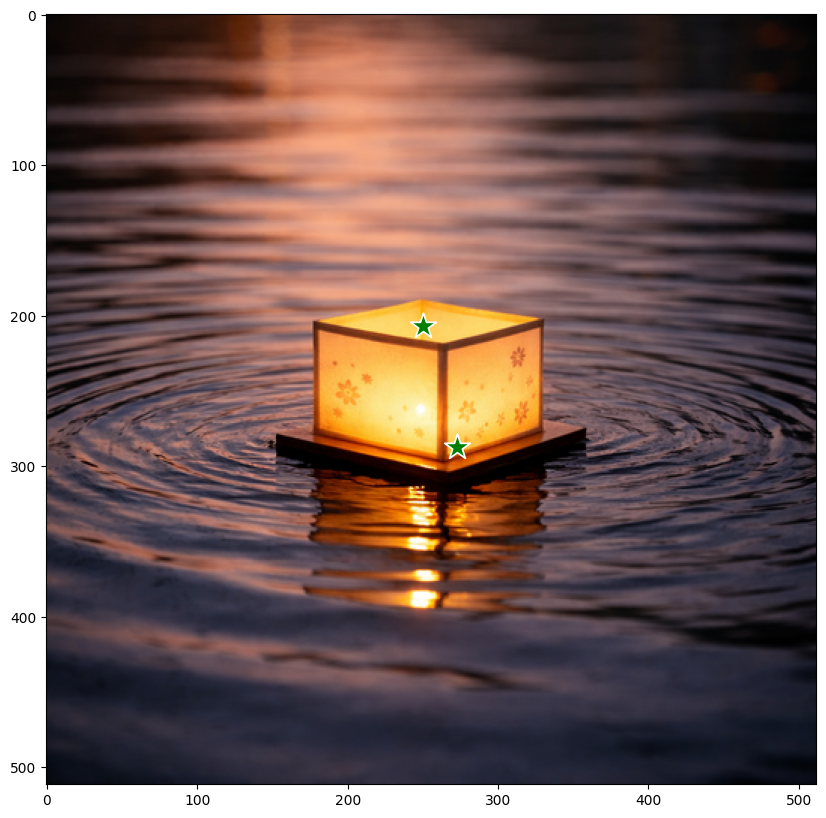

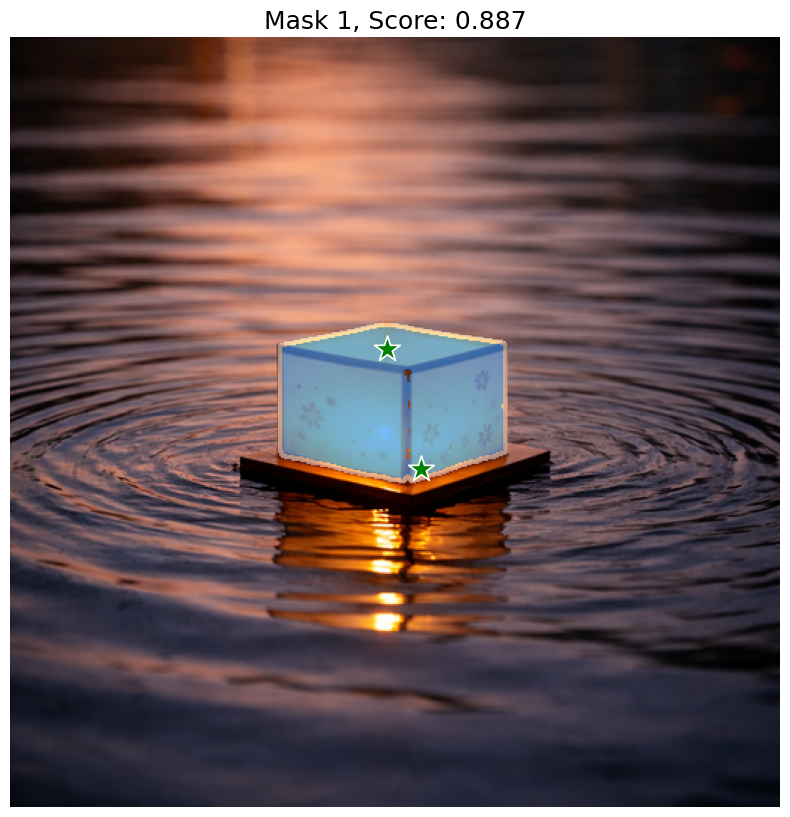

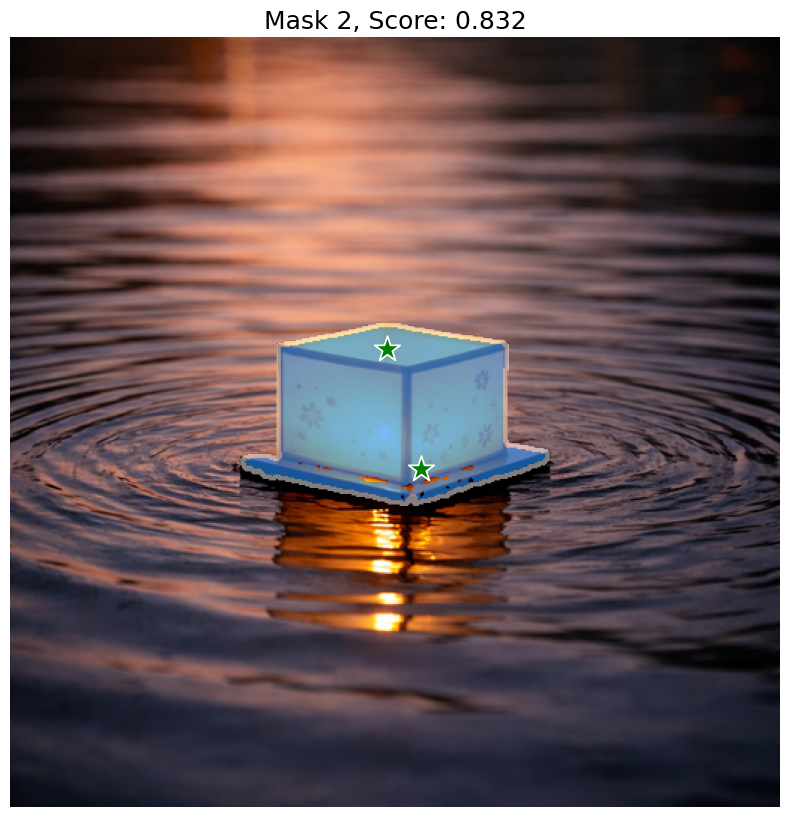

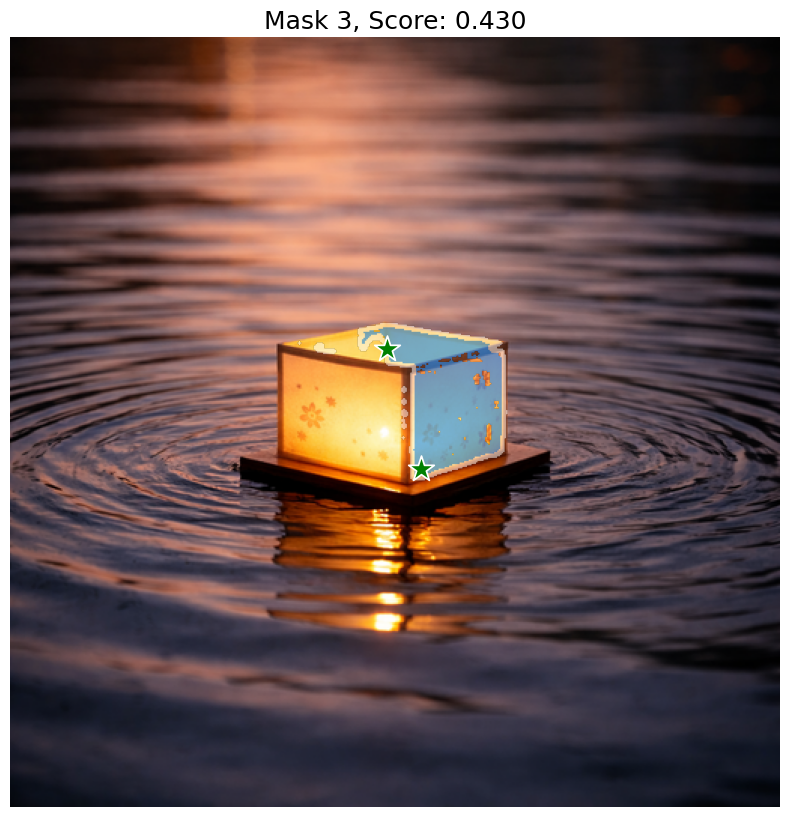

: 

In [ ]:

config_path = "/home/gaoya/Code_Video/RealWonder-main/demo_web/demo_data/lamp/config.yaml"
config = OmegaConf.load(config_path)
timestamp = datetime.now().strftime("%d")
output_folder = os.path.join(config['output_folder'], timestamp)
os.makedirs(output_folder, exist_ok=True)
config['output_folder'] = output_folder
debug = config.get('debug', False)

if debug:
    debug_config_save_path = os.path.join(config['output_folder'], "config.yaml")
    OmegaConf.save(config, debug_config_save_path)

device = torch.device("cuda")
set_seed(config['seed'])

torch.set_grad_enabled(False)
input_image = Image.open(os.path.join(config['data_path'], 'input.png')).convert('RGB')
genesis_simulator = DiffSim(config)




In [4]:
raw_video_frames, points_masks, mesh_masks = genesis_simulator.simulation_pc_render()

  0%|          | 0/81 [00:00<?, ?it/s]

: 

In [ ]:

input_image, video_frames, points_masks_downsampled, mesh_masks_downsampled = process_simulated_results(input_image, raw_video_frames, points_masks, mesh_masks, crop_start=config['crop_start'])

final_sim_folder = os.path.join(output_folder, "final_sim")
os.makedirs(final_sim_folder, exist_ok=True)

config_save_path = os.path.join(final_sim_folder, "config.yaml")
OmegaConf.save(config, config_save_path)

noise_warper = NoiseWarper()
optical_flows = genesis_simulator.svr.optical_flow

optical_flows = np.array(optical_flows)[..., :2]  # shape (71, 512, 512, 2)
optical_flows = np.transpose(optical_flows, (0, 3, 1, 2))  # shape (71, 2, 512, 512)

if debug:
    np.save(os.path.join(final_sim_folder, "flows.npy"), optical_flows)

# save the simulation results
frame_folder = os.path.join(final_sim_folder, "frames")
os.makedirs(frame_folder, exist_ok=True)
for i, frame in enumerate(video_frames):
    frame_path = os.path.join(frame_folder, f"frame_{i:04d}.png")
    frame.save(frame_path)

if debug:
    visualize_optical_flow_advanced(frame_folder, os.path.join(final_sim_folder, "flows.npy"), os.path.join(final_sim_folder, "optical_flow_viz"), arrow_density=30)

# warped_noise = noise_warper.process(optical_flows, final_sim_folder, crop_start=config['crop_start'], input_flow=True, debug=debug)
warped_noise = noise_warper.process(video_frames, final_sim_folder, crop_start=config['crop_start'], input_flow=False, debug=debug)

points_masks_path = os.path.join(final_sim_folder, "points_masks_downsampled.pt")
torch.save(points_masks_downsampled, points_masks_path)
mesh_masks_path = os.path.join(final_sim_folder, "mesh_masks_downsampled.pt")
torch.save(mesh_masks_downsampled, mesh_masks_path)

video_path = os.path.join(final_sim_folder, "simulation.mp4")
save_video_from_pil(video_frames, video_path, fps=10)

input_image_path = os.path.join(final_sim_folder, "resized_input_image.png")
input_image.save(input_image_path)

prompt_txt_path = os.path.join(final_sim_folder, "prompt.txt")
with open(prompt_txt_path, "w") as f:
    f.write(config['vgen_prompt'])